In [1]:
# Cell 1: Install Dependencies and Imports

import sys
import subprocess

# Install additional packages if needed
packages = ['einops']
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
    except:
        pass

# Core imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import time
import gc
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
import nibabel as nib
from scipy.ndimage import gaussian_filter, map_coordinates
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast as autocast_cuda

# For MAE
from einops import rearrange, repeat

print("="*70)
print("MAE-UNET FOR BRAIN TUMOR SEGMENTATION")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

print("="*70)

MAE-UNET FOR BRAIN TUMOR SEGMENTATION
PyTorch version: 2.6.0+cu124
CUDA available: True
Device: cuda
GPU: Tesla T4
GPU Memory: 15.83 GB


In [2]:
# Cell 2: Configuration (Kaggle - CORRECT SSL)

class Config:
    # ========== PATHS (KAGGLE) ==========
    TRAIN_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData'
    VAL_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_ValidationData'
    SAVE_PATH = '/kaggle/working'
    
    # ========== DATA PARAMETERS ==========
    IMG_SIZE = 128
    CHANNELS = 4
    NUM_CLASSES = 4
    SLICE_RANGE = (40, 120)
    
    # ========== SPLITTING ==========
    TRAIN_SPLIT = 0.70  # 70% of 369 = 258
    VAL_SPLIT = 0.15    # 15% of 369 = 55
    TEST_SPLIT = 0.15   # 15% of 369 = 56
    SEED = 42
    
    # ========== MAE ARCHITECTURE ==========
    PATCH_SIZE = 16
    EMBED_DIM = 512
    ENCODER_DEPTH = 6
    DECODER_DEPTH = 4
    NUM_HEADS = 8
    MLP_RATIO = 4
    MASK_RATIO = 0.75
    
    # ========== UNET ARCHITECTURE ==========
    UNET_FEATURES = [64, 128, 256, 512, 1024]
    
    # ========== MAE PRETRAINING ==========
    MAE_EPOCHS = 120
    MAE_BATCH_SIZE = 32
    MAE_LEARNING_RATE = 1.5e-4
    MAE_WEIGHT_DECAY = 0.05
    MAE_WARMUP_EPOCHS = 5
    
    # ========== FINE-TUNING ==========
    FT_EPOCHS = 70
    FT_BATCH_SIZE = 8
    FT_LEARNING_RATE = 1e-4
    FT_WEIGHT_DECAY = 0.05
    PATIENCE = 10
    
    # ========== OPTIMIZATION ==========
    GRADIENT_CLIP = 1.0
    ACCUMULATION_STEPS = 4
    MIXED_PRECISION = True
    
    # ========== SYSTEM ==========
    NUM_WORKERS = 2
    PIN_MEMORY = True

config = Config()

os.makedirs(config.SAVE_PATH, exist_ok=True)
os.makedirs(os.path.join(config.SAVE_PATH, 'checkpoints'), exist_ok=True)

print("SSL Configuration:")
print(f"  MAE Pretraining: 258 (labeled train) + 125 (unlabeled val) = 383 patients")
print(f"  Fine-tuning: 258 train / 55 val / 56 test")

SSL Configuration:
  MAE Pretraining: 258 (labeled train) + 125 (unlabeled val) = 383 patients
  Fine-tuning: 258 train / 55 val / 56 test


In [3]:
# Cell 3: Data Loading Functions

def load_nifti(filepath):
    """Load NIfTI file"""
    nifti = nib.load(filepath)
    data = nifti.get_fdata()
    return data

def load_patient_data(patient_dir):
    """Load all modalities for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Stack channels
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    # Load segmentation mask
    seg_path = os.path.join(patient_dir, f'{patient_id}_seg.nii')
    if os.path.exists(seg_path):
        mask = load_nifti(seg_path)
    else:
        mask = None
    
    return image, mask, patient_id

def get_patient_list(data_path):
    """Get list of patient directories"""
    return sorted([os.path.join(data_path, d) for d in os.listdir(data_path) 
                   if os.path.isdir(os.path.join(data_path, d))])

def remap_mask(mask):
    """Remap mask values: (0,1,2,4) -> (0,1,2,3)"""
    new_mask = mask.copy()
    new_mask[mask == 4] = 3
    return new_mask

def normalize_image(image):
    """Normalize each channel independently"""
    normalized = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[-1]):
        channel = image[..., c]
        if channel.max() > 0:
            mean = channel[channel > 0].mean()
            std = channel[channel > 0].std()
            normalized[..., c] = np.where(channel > 0, (channel - mean) / (std + 1e-8), 0)
    return normalized

def extract_slices_from_patient(image, mask, slice_range, target_size):
    """Extract 2D slices from 3D volume"""
    slices_x = []
    slices_y = []
    
    start_slice, end_slice = slice_range
    
    for slice_idx in range(start_slice, min(end_slice, image.shape[2])):
        img_slice = image[:, :, slice_idx, :]
        
        # Skip empty slices
        if mask is not None:
            mask_slice = mask[:, :, slice_idx]
            if mask_slice.max() == 0:
                continue
        else:
            if img_slice.max() == 0:
                continue
        
        # Normalize
        img_slice = normalize_image(img_slice)
        
        # Resize
        img_slice_resized = cv2.resize(img_slice, (target_size, target_size))
        slices_x.append(img_slice_resized)
        
        if mask is not None:
            mask_slice = remap_mask(mask_slice)
            mask_slice_resized = cv2.resize(mask_slice, (target_size, target_size), 
                                           interpolation=cv2.INTER_NEAREST)
            slices_y.append(mask_slice_resized)
    
    if len(slices_x) > 0:
        slices_x = np.array(slices_x)
        slices_y = np.array(slices_y) if len(slices_y) > 0 else None
    else:
        slices_x = np.array([])
        slices_y = None
    
    return slices_x, slices_y

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


In [4]:
# Cell 4: Process Data - CORRECT SSL STRATEGY

def process_patients_in_memory(patient_list, slice_range, img_size, name, batch_size=10, load_masks=True):
    """Process patients in batches"""
    print(f"⚙️ Processing {len(patient_list)} patients for {name}...")
    
    all_images = []
    all_masks = []
    
    num_batches = (len(patient_list) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(patient_list))
        batch_patients = patient_list[start_idx:end_idx]
        
        print(f"  Batch {batch_idx+1}/{num_batches}: Processing {len(batch_patients)} patients...")
        
        batch_images = []
        batch_masks = []
        
        for patient_dir in tqdm(batch_patients, desc=f"Batch {batch_idx+1}"):
            try:
                image, mask, patient_id = load_patient_data(patient_dir)
                slices_x, slices_y = extract_slices_from_patient(
                    image, mask if load_masks else None, slice_range, img_size
                )
                
                if len(slices_x) > 0:
                    batch_images.append(slices_x)
                    if load_masks and slices_y is not None:
                        batch_masks.append(slices_y)
                
                del image, mask, slices_x, slices_y
                
            except Exception as e:
                print(f"    Error processing {patient_dir}: {e}")
        
        if batch_images:
            all_images.append(np.concatenate(batch_images, axis=0))
            if batch_masks:
                all_masks.append(np.concatenate(batch_masks, axis=0))
        
        del batch_images, batch_masks
        gc.collect()
    
    X = np.concatenate(all_images, axis=0)
    y = np.concatenate(all_masks, axis=0) if all_masks else None
    
    del all_images, all_masks
    gc.collect()
    
    print(f"✅ {name} complete: X={X.shape}, y={y.shape if y is not None else None}")
    
    return X, y


# ========== LOAD ALL PATIENTS ==========
print("="*70)
print("LOADING DATASET")
print("="*70)

labeled_patients = get_patient_list(config.TRAIN_PATH)  # 369 patients
unlabeled_patients = get_patient_list(config.VAL_PATH)  # 125 patients

print(f"Labeled patients (with masks): {len(labeled_patients)}")
print(f"Unlabeled patients (no masks): {len(unlabeled_patients)}")

# ========== SPLIT LABELED DATA ==========
train_patients, temp_patients = train_test_split(
    labeled_patients, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT / (config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

# ========== MAE PRETRAINING PATIENTS ==========
mae_pretrain_patients = train_patients + unlabeled_patients  # 258 + 125 = 383

print(f"\n{'='*70}")
print("DATASET SPLIT")
print("="*70)
print(f"MAE Pretraining (unlabeled): {len(mae_pretrain_patients)} patients")
print(f"  - From labeled train: {len(train_patients)} patients")
print(f"  - From unlabeled val: {len(unlabeled_patients)} patients")
print(f"\nFine-tuning (labeled):")
print(f"  - Train: {len(train_patients)} patients")
print(f"  - Val: {len(val_patients)} patients")
print(f"  - Test: {len(test_patients)} patients")
print("="*70)

# ========== PROCESS DATA ==========
print("\n" + "="*70)
print("PROCESSING DATA")
print("="*70)

print("\n1. Processing MAE pretraining data (no masks needed)...")
X_mae, _ = process_patients_in_memory(
    mae_pretrain_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'MAE_Pretrain', batch_size=10, load_masks=False
)

print("\n2. Processing training data (with masks)...")
X_train, y_train = process_patients_in_memory(
    train_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'Train', batch_size=10, load_masks=True
)

print("\n3. Processing validation data (with masks)...")
X_val, y_val = process_patients_in_memory(
    val_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'Val', batch_size=10, load_masks=True
)

print("\n4. Processing test data (with masks)...")
X_test, y_test = process_patients_in_memory(
    test_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'Test', batch_size=10, load_masks=True
)

print("\n" + "="*70)
print("FINAL DATA SUMMARY")
print("="*70)
print(f"MAE Pretrain (unlabeled): {X_mae.shape}")
print(f"Train (labeled):          {X_train.shape}, {y_train.shape}")
print(f"Val (labeled):            {X_val.shape}, {y_val.shape}")
print(f"Test (labeled):           {X_test.shape}, {y_test.shape}")
print(f"Mask values: {np.unique(y_train)}")
print("="*70)

print(f"\n✅ Data preprocessing complete!")
print(f"\nSSL Strategy Summary:")
print(f"  Phase 1: MAE on {len(mae_pretrain_patients)} patients ({X_mae.shape[0]:,} slices)")
print(f"  Phase 2: Fine-tune on {len(train_patients)} patients ({X_train.shape[0]:,} slices)")
print(f"  Phase 3: Test on {len(test_patients)} patients ({X_test.shape[0]:,} slices)")

LOADING DATASET
Labeled patients (with masks): 369
Unlabeled patients (no masks): 125

DATASET SPLIT
MAE Pretraining (unlabeled): 383 patients
  - From labeled train: 258 patients
  - From unlabeled val: 125 patients

Fine-tuning (labeled):
  - Train: 258 patients
  - Val: 55 patients
  - Test: 56 patients

PROCESSING DATA

1. Processing MAE pretraining data (no masks needed)...
⚙️ Processing 383 patients for MAE_Pretrain...
  Batch 1/39: Processing 10 patients...


Batch 1: 100%|██████████| 10/10 [00:13<00:00,  1.30s/it]


  Batch 2/39: Processing 10 patients...


Batch 2: 100%|██████████| 10/10 [00:13<00:00,  1.31s/it]


  Batch 3/39: Processing 10 patients...


...

  Batch 5/6: Processing 10 patients...


Batch 5: 100%|██████████| 10/10 [00:11<00:00,  1.14s/it]


  Batch 6/6: Processing 6 patients...


Batch 6: 100%|██████████| 6/6 [00:07<00:00,  1.17s/it]


✅ Test complete: X=(3146, 128, 128, 4), y=(3146, 128, 128)

FINAL DATA SUMMARY
MAE Pretrain (unlabeled): (30622, 128, 128, 4)
Train (labeled):          (14942, 128, 128, 4), (14942, 128, 128)
Val (labeled):            (3126, 128, 128, 4), (3126, 128, 128)
Test (labeled):           (3146, 128, 128, 4), (3146, 128, 128)
Mask values: [0. 1. 2. 3.]

✅ Data preprocessing complete!

SSL Strategy Summary:
  Phase 1: MAE on 383 patients (30,622 slices)
  Phase 2: Fine-tune on 258 patients (14,942 slices)
  Phase 3: Test on 56 patients (3,146 slices)


In [5]:
# Cell 5: MAE Dataset for Pretraining

class MAEDataset(Dataset):
    """Dataset for MAE pretraining (no labels needed)"""
    def __init__(self, images):
        self.images = images
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        
        # Convert to tensor: (H, W, C) -> (C, H, W)
        image = torch.from_numpy(image).float().permute(2, 0, 1)
        
        return image

# Create MAE dataset
mae_dataset = MAEDataset(X_mae)

mae_loader = DataLoader(
    mae_dataset,
    batch_size=config.MAE_BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=True
)

print("="*70)
print("MAE DATASET")
print("="*70)
print(f"Total samples: {len(mae_dataset)}")
print(f"Total batches: {len(mae_loader)}")
print(f"Batch size: {config.MAE_BATCH_SIZE}")
print("="*70)

MAE DATASET
Total samples: 30622
Total batches: 956
Batch size: 32


In [6]:
# Cell 6: MAE Components - Patch Embedding and Masking

class PatchEmbed(nn.Module):
    """Convert image to patch embeddings"""
    def __init__(self, img_size=128, patch_size=16, in_chans=4, embed_dim=512):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


def random_masking(x, mask_ratio):
    """
    Perform random masking by shuffling.
    x: (B, N, D) - batch, num_patches, embed_dim
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))
    
    # Generate random noise for shuffling
    noise = torch.rand(B, N, device=x.device)
    
    # Sort noise to get shuffle indices
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    # Keep the first subset
    ids_keep = ids_shuffle[:, :len_keep]
    x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
    
    # Generate binary mask: 0 is keep, 1 is remove
    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_masked, mask, ids_restore


print("✅ Patch embedding and masking functions defined!")

✅ Patch embedding and masking functions defined!


In [7]:
# Cell 7: Transformer Blocks for MAE

class Attention(nn.Module):
    """Multi-head self-attention"""
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    """MLP block"""
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(nn.Module):
    """Transformer block"""
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, drop=drop)
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


print("✅ Transformer blocks defined!")

✅ Transformer blocks defined!


In [8]:
# Cell 8: Complete MAE Model

class MAE(nn.Module):
    """Masked Autoencoder with Vision Transformer backbone"""
    def __init__(self, img_size=128, patch_size=16, in_chans=4,
                 embed_dim=512, encoder_depth=6, decoder_depth=4,
                 num_heads=8, mlp_ratio=4., norm_pix_loss=False):
        super().__init__()
        
        # Encoder
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        self.encoder_blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True)
            for _ in range(encoder_depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)
        
        # Decoder
        decoder_embed_dim = embed_dim // 2
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim))
        
        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, num_heads, mlp_ratio, qkv_bias=True)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        
        # Reconstruction head
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans)
        
        self.norm_pix_loss = norm_pix_loss
        self.patch_size = patch_size
        
        self.initialize_weights()
        
        print(f"MAE Model:")
        print(f"  Image size: {img_size}x{img_size}")
        print(f"  Patch size: {patch_size}x{patch_size}")
        print(f"  Num patches: {num_patches}")
        print(f"  Embed dim: {embed_dim}")
        print(f"  Encoder depth: {encoder_depth}")
        print(f"  Decoder depth: {decoder_depth}")
    
    def initialize_weights(self):
        # Initialize position embeddings
        torch.nn.init.normal_(self.pos_embed, std=.02)
        torch.nn.init.normal_(self.decoder_pos_embed, std=.02)
        
        # Initialize cls token and mask token
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def patchify(self, imgs):
        """Convert images to patches"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h = H // p
        w = W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(B, h * w, p**2 * C)
        return x
    
    def unpatchify(self, x):
        """Convert patches back to images"""
        p = self.patch_size
        h = w = int(x.shape[1]**.5)
        x = x.reshape(x.shape[0], h, w, p, p, -1)
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(x.shape[0], -1, h * p, w * p)
        return imgs
    
    def forward_encoder(self, x, mask_ratio):
        # Patch embedding
        x = self.patch_embed(x)
        
        # Add position embeddings (without cls token)
        x = x + self.pos_embed[:, 1:, :]
        
        # Masking
        x, mask, ids_restore = random_masking(x, mask_ratio)
        
        # Add cls token
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Encoder blocks
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)
        
        return x, mask, ids_restore
    
    def forward_decoder(self, x, ids_restore):
        # Embed tokens
        x = self.decoder_embed(x)
        
        # Append mask tokens
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)
        
        # Add position embeddings
        x = x + self.decoder_pos_embed
        
        # Decoder blocks
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)
        
        # Predictor
        x = self.decoder_pred(x)
        
        # Remove cls token
        x = x[:, 1:, :]
        
        return x
    
    def forward_loss(self, imgs, pred, mask):
        """Compute reconstruction loss"""
        target = self.patchify(imgs)
        
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # Mean per patch
        
        loss = (loss * mask).sum() / mask.sum()  # Mean loss on removed patches
        return loss
    
    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


# Create MAE model
mae_model = MAE(
    img_size=config.IMG_SIZE,
    patch_size=config.PATCH_SIZE,
    in_chans=config.CHANNELS,
    embed_dim=config.EMBED_DIM,
    encoder_depth=config.ENCODER_DEPTH,
    decoder_depth=config.DECODER_DEPTH,
    num_heads=config.NUM_HEADS,
    mlp_ratio=config.MLP_RATIO
).to(device)

# Count parameters
total_params = sum(p.numel() for p in mae_model.parameters())
trainable_params = sum(p.numel() for p in mae_model.parameters() if p.requires_grad)

print(f"\n{'='*70}")
print("MAE MODEL CREATED")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1e6:.2f} MB")
print("="*70)

# Test forward pass
print("\n🧪 Testing MAE model...")
try:
    test_input = torch.randn(2, config.CHANNELS, config.IMG_SIZE, config.IMG_SIZE).to(device)
    with torch.no_grad():
        test_loss, test_pred, test_mask = mae_model(test_input, config.MASK_RATIO)
    
    print(f"✅ MAE test passed!")
    print(f"   Input: {test_input.shape}")
    print(f"   Loss: {test_loss.item():.4f}")
    print(f"   Pred: {test_pred.shape}")
    print(f"   Mask: {test_mask.shape}")
    
    del test_input, test_loss, test_pred, test_mask
    torch.cuda.empty_cache()
except Exception as e:
    print(f"❌ MAE test failed: {e}")
    raise

print("\n✅ MAE model ready for pretraining!")

MAE Model:
  Image size: 128x128
  Patch size: 16x16
  Num patches: 64
  Embed dim: 512
  Encoder depth: 6
  Decoder depth: 4

MAE MODEL CREATED
Total parameters: 23,044,864
Trainable parameters: 23,044,864
Model size: 92.18 MB

🧪 Testing MAE model...
✅ MAE test passed!
   Input: torch.Size([2, 4, 128, 128])
   Loss: 1.4364
   Pred: torch.Size([2, 64, 1024])
   Mask: torch.Size([2, 64])

✅ MAE model ready for pretraining!


In [9]:
# Cell 9: MAE Pretraining Loop (FINAL FIX)

print("\n" + "="*70)
print("PHASE 1: MAE PRETRAINING")
print("="*70)
print(f"Epochs: {config.MAE_EPOCHS}")
print(f"Batch size: {config.MAE_BATCH_SIZE}")
print(f"Learning rate: {config.MAE_LEARNING_RATE}")
print(f"Mask ratio: {config.MASK_RATIO}")
print(f"Training samples: {len(mae_dataset):,}")
print("="*70)

# Optimizer
mae_optimizer = optim.AdamW(
    mae_model.parameters(),
    lr=config.MAE_LEARNING_RATE,
    weight_decay=config.MAE_WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

# Learning rate scheduler with warmup
def adjust_learning_rate(optimizer, epoch, warmup_epochs, total_epochs, base_lr, min_lr=0):
    """Cosine schedule with warmup"""
    if epoch < warmup_epochs:
        lr = base_lr * epoch / warmup_epochs
    else:
        lr = min_lr + (base_lr - min_lr) * 0.5 * (
            1. + np.cos(np.pi * (epoch - warmup_epochs) / (total_epochs - warmup_epochs))
        )
    
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    return lr

# Gradient scaler
scaler = GradScaler()

# Training history
mae_history = {'train_loss': [], 'lr': []}

# Training loop
mae_start_time = time.time()
best_mae_loss = float('inf')

for epoch in range(config.MAE_EPOCHS):
    epoch_start = time.time()
    
    # Adjust learning rate
    current_lr = adjust_learning_rate(
        mae_optimizer, epoch, config.MAE_WARMUP_EPOCHS, 
        config.MAE_EPOCHS, config.MAE_LEARNING_RATE
    )
    
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.MAE_EPOCHS}")
    print(f"Learning Rate: {current_lr:.6f}")
    print(f"{'='*70}")
    
    # Train
    mae_model.train()
    running_loss = 0.0
    
    pbar = tqdm(mae_loader, desc='MAE Pretraining')
    for batch_idx, images in enumerate(pbar):
        images = images.to(device)
        
        # Forward pass - FIXED for old PyTorch
        if config.MIXED_PRECISION:
            with autocast_cuda():
                loss, _, _ = mae_model(images, config.MASK_RATIO)
        else:
            loss, _, _ = mae_model(images, config.MASK_RATIO)
        
        # Backward pass
        mae_optimizer.zero_grad()
        
        if config.MIXED_PRECISION:
            scaler.scale(loss).backward()
            scaler.step(mae_optimizer)
            scaler.update()
        else:
            loss.backward()
            mae_optimizer.step()
        
        running_loss += loss.item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Epoch summary
    epoch_loss = running_loss / len(mae_loader)
    epoch_time = time.time() - epoch_start
    
    mae_history['train_loss'].append(epoch_loss)
    mae_history['lr'].append(current_lr)
    
    # Check for improvement
    if epoch_loss < best_mae_loss:
        best_mae_loss = epoch_loss
        improvement = "🎯 New best!"
    else:
        improvement = ""
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Loss: {epoch_loss:.4f} {improvement}")
    print(f"  Time: {epoch_time/60:.2f} min")
    print(f"  Total: {(time.time() - mae_start_time)/3600:.2f} hours")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == config.MAE_EPOCHS - 1:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': mae_model.state_dict(),
            'optimizer_state_dict': mae_optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_mae_loss,
            'history': mae_history
        }
        
        checkpoint_path = os.path.join(config.SAVE_PATH, 'checkpoints', f'mae_epoch_{epoch+1}.pth')
        torch.save(checkpoint, checkpoint_path)
        print(f"  💾 Checkpoint saved: epoch_{epoch+1}.pth")
    
    # Free memory
    torch.cuda.empty_cache()
    gc.collect()

mae_total_time = time.time() - mae_start_time

print("\n" + "="*70)
print("✅ MAE PRETRAINING COMPLETED!")
print("="*70)
print(f"Total time: {mae_total_time/3600:.2f} hours")
print(f"Final loss: {mae_history['train_loss'][-1]:.4f}")
print(f"Best loss: {best_mae_loss:.4f}")
print("="*70)

# Save encoder weights
encoder_path = os.path.join(config.SAVE_PATH, 'mae_encoder.pth')
torch.save(mae_model.patch_embed.state_dict(), encoder_path)
print(f"✅ Encoder weights saved to: mae_encoder.pth")

# Save history
with open(os.path.join(config.SAVE_PATH, 'mae_history.json'), 'w') as f:
    json.dump(mae_history, f, indent=4)
print(f"✅ Training history saved!")


PHASE 1: MAE PRETRAINING
Epochs: 120
Batch size: 32
Learning rate: 0.00015
Mask ratio: 0.75
Training samples: 30,622

Epoch 1/120
Learning Rate: 0.000000


MAE Pretraining: 100%|██████████| 956/956 [00:40<00:00, 23.40it/s, loss=0.6662]



Epoch 1 Summary:
  Loss: 0.6708 🎯 New best!
  Time: 0.68 min
  Total: 0.01 hours

Epoch 2/120
Learning Rate: 0.000030


MAE Pretraining: 100%|██████████| 956/956 [00:40<00:00, 23.65it/s, loss=0.2233]



Epoch 2 Summary:
  Loss: 0.2364 🎯 New best!
  Time: 0.67 min
  Total: 0.02 hours

Epoch 3/120
Learning Rate: 0.000060


...


Epoch 118 Summary:
  Loss: 0.0791 
  Time: 0.68 min
  Total: 1.34 hours

Epoch 119/120
Learning Rate: 0.000000


MAE Pretraining: 100%|██████████| 956/956 [00:41<00:00, 23.28it/s, loss=0.0791]



Epoch 119 Summary:
  Loss: 0.0791 
  Time: 0.68 min
  Total: 1.35 hours

Epoch 120/120
Learning Rate: 0.000000


MAE Pretraining: 100%|██████████| 956/956 [00:41<00:00, 23.30it/s, loss=0.0834]



Epoch 120 Summary:
  Loss: 0.0790 🎯 New best!
  Time: 0.68 min
  Total: 1.36 hours
  💾 Checkpoint saved: epoch_120.pth

✅ MAE PRETRAINING COMPLETED!
Total time: 1.36 hours
Final loss: 0.0790
Best loss: 0.0790
✅ Encoder weights saved to: mae_encoder.pth
✅ Training history saved!


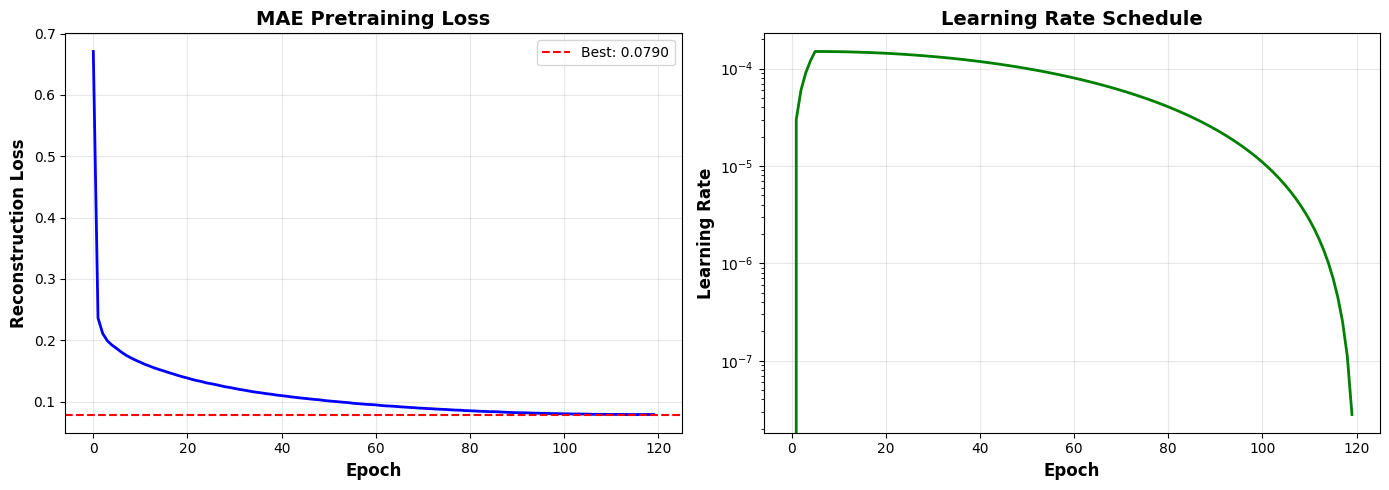

✅ MAE training history plotted!


In [10]:
# Cell 10: Plot MAE Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(mae_history['train_loss'], linewidth=2, color='blue')
axes[0].axhline(y=best_mae_loss, color='red', linestyle='--', 
               label=f'Best: {best_mae_loss:.4f}', linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Reconstruction Loss', fontsize=12, fontweight='bold')
axes[0].set_title('MAE Pretraining Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate plot
axes[1].plot(mae_history['lr'], linewidth=2, color='green')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'mae_training.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ MAE training history plotted!")

In [11]:
# Cell 11: U-Net with MAE Pretrained Encoder

class ConvBlock(nn.Module):
    """Convolutional block for U-Net"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class EncoderBlock(nn.Module):
    """Encoder block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2, 2)
    
    def forward(self, x):
        skip = self.conv(x)
        x = self.pool(skip)
        return skip, x


class DecoderBlock(nn.Module):
    """Decoder block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = ConvBlock(out_channels * 2, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        
        # Handle size mismatch
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    """U-Net for segmentation"""
    def __init__(self, in_channels=4, num_classes=4, features=[64, 128, 256, 512, 1024]):
        super().__init__()
        
        self.input_conv = nn.Conv2d(in_channels, features[0], 1)
        
        # Encoder
        self.encoder1 = EncoderBlock(features[0], features[0])
        self.encoder2 = EncoderBlock(features[0], features[1])
        self.encoder3 = EncoderBlock(features[1], features[2])
        self.encoder4 = EncoderBlock(features[2], features[3])
        
        # Bottleneck
        self.bottleneck = ConvBlock(features[3], features[4])
        
        # Decoder
        self.decoder4 = DecoderBlock(features[4], features[3])
        self.decoder3 = DecoderBlock(features[3], features[2])
        self.decoder2 = DecoderBlock(features[2], features[1])
        self.decoder1 = DecoderBlock(features[1], features[0])
        
        # Output
        self.out = nn.Conv2d(features[0], num_classes, 1)
        
        print(f"U-Net Model:")
        print(f"  Input channels: {in_channels}")
        print(f"  Output classes: {num_classes}")
        print(f"  Features: {features}")
    
    def forward(self, x):
        # Initial conv
        x = self.input_conv(x)
        
        # Encoder
        s1, x = self.encoder1(x)
        s2, x = self.encoder2(x)
        s3, x = self.encoder3(x)
        s4, x = self.encoder4(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder
        x = self.decoder4(x, s4)
        x = self.decoder3(x, s3)
        x = self.decoder2(x, s2)
        x = self.decoder1(x, s1)
        
        # Output
        x = self.out(x)
        
        return x


# Create U-Net model
unet_model = UNet(
    in_channels=config.CHANNELS,
    num_classes=config.NUM_CLASSES,
    features=config.UNET_FEATURES
).to(device)

# Load pretrained encoder weights from MAE
print("\n" + "="*70)
print("LOADING MAE PRETRAINED WEIGHTS")
print("="*70)

try:
    # Load MAE encoder
    mae_encoder_state = mae_model.patch_embed.state_dict()
    
    # The MAE patch_embed is a Conv2d that projects patches
    # We can use it to initialize the first conv layer
    if 'proj.weight' in mae_encoder_state:
        pretrained_weight = mae_encoder_state['proj.weight']
        
        # MAE: (embed_dim, in_chans, patch_size, patch_size)
        # U-Net input_conv: (features[0], in_chans, 1, 1)
        
        # Average pool the pretrained weights to 1x1
        pretrained_1x1 = F.adaptive_avg_pool2d(pretrained_weight, (1, 1))
        
        # Match the channel dimension
        if pretrained_1x1.shape[0] >= config.UNET_FEATURES[0]:
            pretrained_1x1 = pretrained_1x1[:config.UNET_FEATURES[0], :, :, :]
        
        unet_model.input_conv.weight.data = pretrained_1x1
        
        print(f"✅ Loaded MAE pretrained weights!")
        print(f"   MAE encoder shape: {pretrained_weight.shape}")
        print(f"   U-Net input conv shape: {pretrained_1x1.shape}")
    else:
        print("⚠️ No pretrained weights found, using random initialization")

except Exception as e:
    print(f"⚠️ Could not load pretrained weights: {e}")
    print("   Continuing with random initialization")

print("="*70)

# Count parameters
total_params = sum(p.numel() for p in unet_model.parameters())
trainable_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)

print(f"\nU-Net Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1e6:.2f} MB")

# Test forward pass
print("\n🧪 Testing U-Net...")
try:
    test_input = torch.randn(2, config.CHANNELS, config.IMG_SIZE, config.IMG_SIZE).to(device)
    with torch.no_grad():
        test_output = unet_model(test_input)
    
    print(f"✅ U-Net test passed!")
    print(f"   Input: {test_input.shape}")
    print(f"   Output: {test_output.shape}")
    
    del test_input, test_output
    torch.cuda.empty_cache()
except Exception as e:
    print(f"❌ U-Net test failed: {e}")
    raise

print("\n✅ U-Net ready for fine-tuning!")

U-Net Model:
  Input channels: 4
  Output classes: 4
  Features: [64, 128, 256, 512, 1024]

LOADING MAE PRETRAINED WEIGHTS
✅ Loaded MAE pretrained weights!
   MAE encoder shape: torch.Size([512, 4, 16, 16])
   U-Net input conv shape: torch.Size([64, 4, 1, 1])

U-Net Statistics:
  Total parameters: 31,073,284
  Trainable parameters: 31,073,284
  Model size: 124.29 MB

🧪 Testing U-Net...
✅ U-Net test passed!
   Input: torch.Size([2, 4, 128, 128])
   Output: torch.Size([2, 4, 128, 128])

✅ U-Net ready for fine-tuning!


In [12]:
# Cell 12: Segmentation Dataset

class SegmentationDataset(Dataset):
    """Dataset for segmentation with augmentation"""
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        mask = self.masks[idx].copy()
        
        if self.augment and np.random.rand() > 0.5:
            # Horizontal flip
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)
            
            # Vertical flip
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)
            
            # Random rotation (90, 180, 270)
            if np.random.rand() > 0.5:
                k = np.random.choice([1, 2, 3])
                image = np.rot90(image, k, axes=(0, 1))
                mask = np.rot90(mask, k, axes=(0, 1))
            
            # Random brightness/contrast
            if np.random.rand() > 0.5:
                for c in range(image.shape[-1]):
                    alpha = np.random.uniform(0.85, 1.15)
                    beta = np.random.uniform(-0.15, 0.15)
                    image[:, :, c] = alpha * image[:, :, c] + beta
            
            # Clip
            image = np.clip(image, -3, 3)
        
        # Convert to tensor
        image = torch.from_numpy(image.copy()).float().permute(2, 0, 1)
        mask = torch.from_numpy(mask.copy()).long()
        mask = torch.clamp(mask, 0, config.NUM_CLASSES - 1)
        
        return image, mask


# Create datasets
train_dataset = SegmentationDataset(X_train, y_train, augment=True)
val_dataset = SegmentationDataset(X_val, y_val, augment=False)
test_dataset = SegmentationDataset(X_test, y_test, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

print("="*70)
print("SEGMENTATION DATASETS")
print("="*70)
print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")
print("="*70)

SEGMENTATION DATASETS
Train: 14942 samples, 1867 batches
Val:   3126 samples, 391 batches
Test:  3146 samples, 394 batches


In [13]:
# Cell 13: Loss Functions and Metrics

class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # pred: (B, C, H, W)
        # target: (B, H, W)
        pred = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1])
        target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()
        
        intersection = (pred * target_one_hot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Combined Dice + CrossEntropy Loss"""
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


def calculate_dice_score(pred, target, num_classes=4):
    """Calculate mean Dice score"""
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    dice_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum()).item()
        
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_scores.append(dice)
    
    return np.mean(dice_scores)


def calculate_iou_score(pred, target, num_classes=4):
    """Calculate mean IoU score"""
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    iou_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum() - intersection).item()
        
        if union == 0:
            iou_scores.append(1.0)
        else:
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.append(iou)
    
    return np.mean(iou_scores)


print("✅ Loss functions and metrics defined!")

# Test loss function
print("\n🧪 Testing loss functions...")
try:
    test_pred = torch.randn(2, 4, 128, 128)
    test_target = torch.randint(0, 4, (2, 128, 128))
    
    test_criterion = CombinedLoss()
    test_loss = test_criterion(test_pred, test_target)
    test_dice = calculate_dice_score(test_pred, test_target)
    test_iou = calculate_iou_score(test_pred, test_target)
    
    print(f"✅ Loss test passed!")
    print(f"   Loss: {test_loss.item():.4f}")
    print(f"   Dice: {test_dice:.4f}")
    print(f"   IoU: {test_iou:.4f}")
    
    del test_pred, test_target, test_loss
    
except Exception as e:
    print(f"❌ Loss test failed: {e}")
    raise

✅ Loss functions and metrics defined!

🧪 Testing loss functions...
✅ Loss test passed!
   Loss: 1.2349
   Dice: 0.2477
   IoU: 0.1414


In [14]:
# Cell 14: Training and Validation Functions (FIXED)

def train_epoch(model, dataloader, criterion, optimizer, scaler, device, accumulation_steps=1):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    optimizer.zero_grad()
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass - FIXED
        if config.MIXED_PRECISION and torch.cuda.is_available():
            with autocast_cuda():
                outputs = model(images)
                loss = criterion(outputs, masks)
                loss = loss / accumulation_steps
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss = loss / accumulation_steps
        
        # Backward pass
        if config.MIXED_PRECISION and torch.cuda.is_available():
            scaler.scale(loss).backward()
        else:
            loss.backward()
        
        # Update weights every accumulation_steps
        if (batch_idx + 1) % accumulation_steps == 0:
            if config.MIXED_PRECISION and torch.cuda.is_available():
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 
                                              max_norm=config.GRADIENT_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 
                                              max_norm=config.GRADIENT_CLIP)
                optimizer.step()
            
            optimizer.zero_grad()
        
        # Calculate metrics
        with torch.no_grad():
            dice = calculate_dice_score(outputs.detach(), masks)
            iou = calculate_iou_score(outputs.detach(), masks)
        
        running_loss += loss.item() * accumulation_steps
        running_dice += dice
        running_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Validation')
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # FIXED
            if config.MIXED_PRECISION and torch.cuda.is_available():
                with autocast_cuda():
                    outputs = model(images)
                    loss = criterion(outputs, masks)
            else:
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            dice = calculate_dice_score(outputs, masks)
            iou = calculate_iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


print("✅ Training functions defined!")

✅ Training functions defined!


In [15]:
# Cell 15: Fine-tuning Training Loop

print("\n" + "="*70)
print("PHASE 2: FINE-TUNING U-NET")
print("="*70)
print(f"Total epochs: {config.FT_EPOCHS}")
print(f"Batch size: {config.FT_BATCH_SIZE}")
print(f"Learning rate: {config.FT_LEARNING_RATE}")
print(f"Patience: {config.PATIENCE}")
print("="*70)

# Loss function
criterion = CombinedLoss()

# Optimizer
optimizer = optim.AdamW(
    unet_model.parameters(),
    lr=config.FT_LEARNING_RATE,
    weight_decay=config.FT_WEIGHT_DECAY
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=10,
    min_lr=1e-7
)

# Gradient scaler
scaler = GradScaler(enabled=config.MIXED_PRECISION)

# Training history
ft_history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': [], 'lr': []
}

# Training loop
ft_start_time = time.time()
best_val_dice = 0.0
patience_counter = 0

for epoch in range(config.FT_EPOCHS):
    epoch_start = time.time()
    
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.FT_EPOCHS}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_dice, train_iou = train_epoch(
        unet_model, train_loader, criterion, optimizer, scaler, device,
        accumulation_steps=config.ACCUMULATION_STEPS
    )
    
    # Validate
    val_loss, val_dice, val_iou = validate_epoch(
        unet_model, val_loader, criterion, device
    )
    
    # Update scheduler
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_dice)
    current_lr = optimizer.param_groups[0]['lr']
    
    if current_lr < old_lr:
        print(f"  📉 Learning rate reduced: {old_lr:.6f} → {current_lr:.6f}")
    
    epoch_time = time.time() - epoch_start
    
    # Update history
    ft_history['train_loss'].append(train_loss)
    ft_history['train_dice'].append(train_dice)
    ft_history['train_iou'].append(train_iou)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_dice'].append(val_dice)
    ft_history['val_iou'].append(val_iou)
    ft_history['lr'].append(current_lr)
    
    gap = abs(train_dice - val_dice)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
    print(f"  Gap   - Dice: {gap:.4f} ({'✅ Healthy' if gap < 0.05 else '⚠️ Watch' if gap < 0.10 else '❌ Overfitting'})")
    print(f"  LR    - {current_lr:.6f}")
    print(f"  Time  - {epoch_time/60:.2f} min")
    print(f"  Total - {(time.time() - ft_start_time)/3600:.2f} hours")
    
    # Check for improvement
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        patience_counter = 0
        
        # Save best model
        best_model_path = os.path.join(config.SAVE_PATH, 'checkpoints', 'unet_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': unet_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'history': ft_history
        }, best_model_path)
        
        print(f"  🎯 New best validation Dice: {best_val_dice:.4f}")
        print(f"  💾 Best model saved!")
    else:
        patience_counter += 1
        print(f"  ⏳ Patience: {patience_counter}/{config.PATIENCE}")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(config.SAVE_PATH, 'checkpoints', f'unet_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': unet_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': ft_history
        }, checkpoint_path)
        print(f"  💾 Checkpoint saved: epoch_{epoch+1}.pth")
    
    # Early stopping
    if patience_counter >= config.PATIENCE:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        print(f"   No improvement for {config.PATIENCE} epochs")
        break
    
    # Free memory
    torch.cuda.empty_cache()
    gc.collect()

ft_total_time = time.time() - ft_start_time

print("\n" + "="*70)
print("✅ FINE-TUNING COMPLETED!")
print("="*70)
print(f"Total time: {ft_total_time/3600:.2f} hours")
print(f"Best validation Dice: {best_val_dice:.4f}")
print(f"Final train-val gap: {abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1]):.4f}")
print("="*70)

# Save final results
results = {
    'mae_pretraining': {
        'epochs': config.MAE_EPOCHS,
        'final_loss': mae_history['train_loss'][-1],
        'best_loss': best_mae_loss,
        'training_time_hours': mae_total_time / 3600
    },
    'fine_tuning': {
        'total_epochs': len(ft_history['train_loss']),
        'best_val_dice': float(best_val_dice),
        'final_train_dice': float(ft_history['train_dice'][-1]),
        'final_val_dice': float(ft_history['val_dice'][-1]),
        'final_gap': float(abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1])),
        'training_time_hours': ft_total_time / 3600
    }
}

with open(os.path.join(config.SAVE_PATH, 'mae_unet_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

# Save history
with open(os.path.join(config.SAVE_PATH, 'finetune_history.json'), 'w') as f:
    json.dump(ft_history, f, indent=4)

print("✅ Results saved!")


PHASE 2: FINE-TUNING U-NET
Total epochs: 70
Batch size: 8
Learning rate: 0.0001
Patience: 10

Epoch 1/70


Validation: 100%|██████████| 391/391 [00:09<00:00, 41.21it/s, loss=0.4818, dice=0.4697, iou=0.4458]



Epoch 1 Summary:
  Train - Loss: 0.6462, Dice: 0.6467, IoU: 0.5483
  Val   - Loss: 0.4695, Dice: 0.6692, IoU: 0.6004
  Gap   - Dice: 0.0225 (✅ Healthy)
  LR    - 0.000100
  Time  - 2.29 min
  Total - 0.04 hours
  🎯 New best validation Dice: 0.6692
  💾 Best model saved!

Epoch 2/70


Validation: 100%|██████████| 391/391 [00:09<00:00, 42.45it/s, loss=0.3913, dice=0.4557, iou=0.4246]



Epoch 2 Summary:
  Train - Loss: 0.3795, Dice: 0.7977, IoU: 0.6896
  Val   - Loss: 0.3569, Dice: 0.6945, IoU: 0.6269
  Gap   - Dice: 0.1032 (❌ Overfitting)
  LR    - 0.000100
  Time  - 2.26 min
  Total - 0.08 hours
  🎯 New best validation Dice: 0.6945
  💾 Best model saved!

Epoch 3/70


...


Epoch 15 Summary:
  Train - Loss: 0.1725, Dice: 0.8809, IoU: 0.7985
  Val   - Loss: 0.2149, Dice: 0.6943, IoU: 0.6260
  Gap   - Dice: 0.1865 (❌ Overfitting)
  LR    - 0.000100
  Time  - 2.26 min
  Total - 0.57 hours
  ⏳ Patience: 8/10

Epoch 16/70


Validation: 100%|██████████| 391/391 [00:09<00:00, 42.27it/s, loss=0.2910, dice=0.6952, iou=0.6598]



Epoch 16 Summary:
  Train - Loss: 0.1711, Dice: 0.8839, IoU: 0.8025
  Val   - Loss: 0.2100, Dice: 0.7294, IoU: 0.6618
  Gap   - Dice: 0.1544 (❌ Overfitting)
  LR    - 0.000100
  Time  - 2.27 min
  Total - 0.61 hours
  ⏳ Patience: 9/10

Epoch 17/70


Validation: 100%|██████████| 391/391 [00:09<00:00, 42.39it/s, loss=0.2650, dice=0.7324, iou=0.7170]


Epoch 17 Summary:
  Train - Loss: 0.1692, Dice: 0.8859, IoU: 0.8059
  Val   - Loss: 0.2141, Dice: 0.7223, IoU: 0.6555
  Gap   - Dice: 0.1636 (❌ Overfitting)
  LR    - 0.000100
  Time  - 2.27 min
  Total - 0.64 hours
  ⏳ Patience: 10/10

⚠️ Early stopping triggered at epoch 17
   No improvement for 10 epochs

✅ FINE-TUNING COMPLETED!
Total time: 0.64 hours
Best validation Dice: 0.7352
Final train-val gap: 0.1636
✅ Results saved!


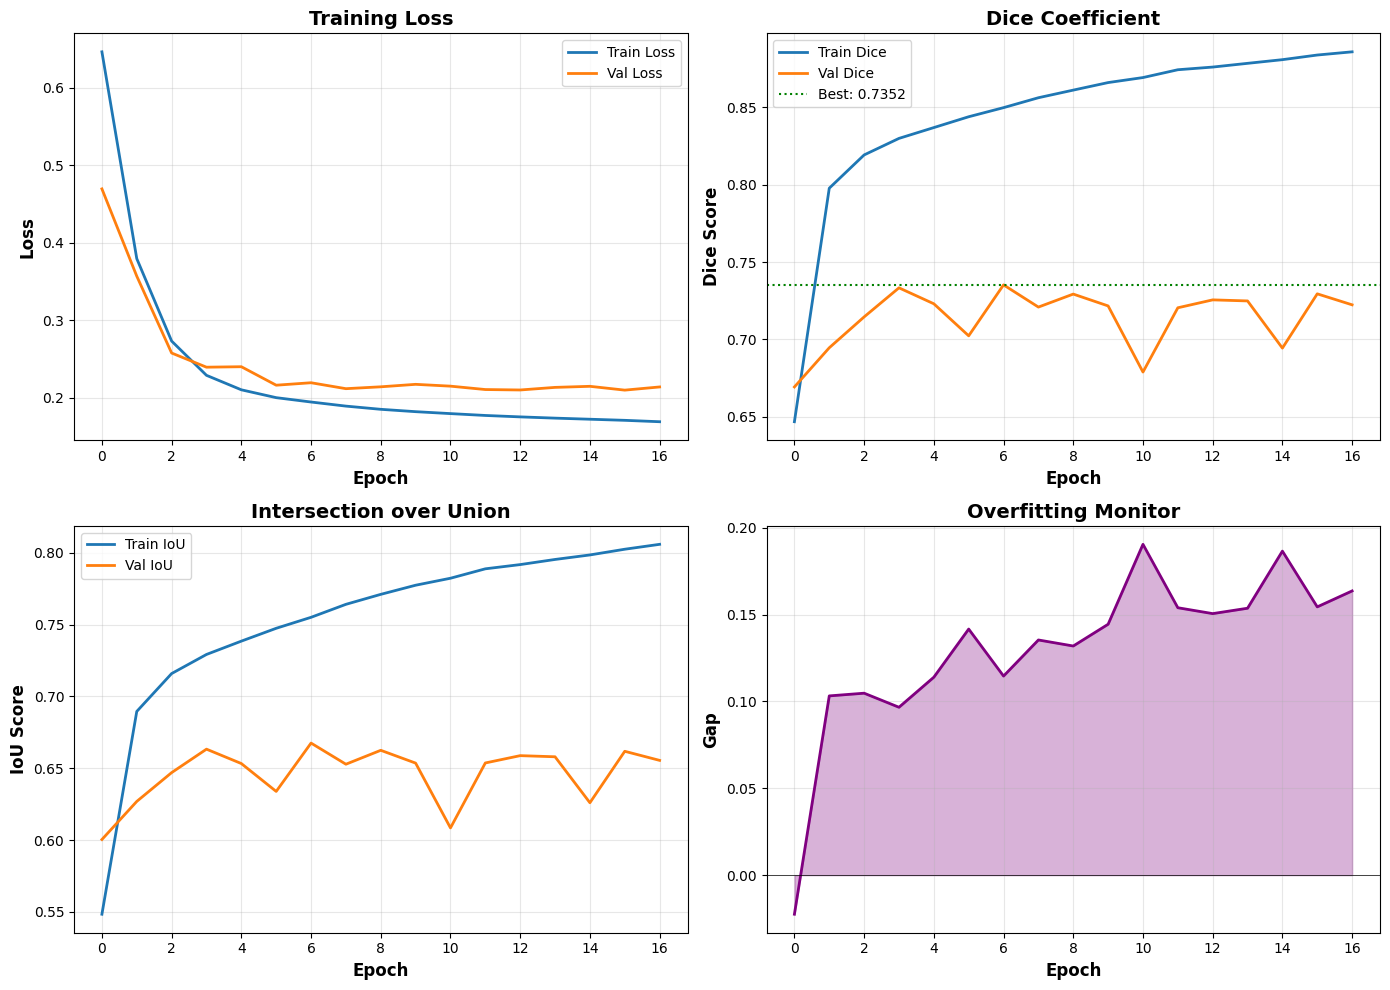

✅ Fine-tuning history plotted!


In [16]:
# Cell 16: Plot Fine-tuning History

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(ft_history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(ft_history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(ft_history['train_dice'], label='Train Dice', linewidth=2)
axes[0, 1].plot(ft_history['val_dice'], label='Val Dice', linewidth=2)
axes[0, 1].axhline(y=best_val_dice, color='green', linestyle=':', 
                   label=f'Best: {best_val_dice:.4f}', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[1, 0].plot(ft_history['train_iou'], label='Train IoU', linewidth=2)
axes[1, 0].plot(ft_history['val_iou'], label='Val IoU', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('IoU Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Intersection over Union', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train-Val Gap
gap = np.array(ft_history['train_dice']) - np.array(ft_history['val_dice'])
axes[1, 1].plot(gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].fill_between(range(len(gap)), 0, gap, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Gap', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overfitting Monitor', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'finetuning_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Fine-tuning history plotted!")

In [17]:
# Cell 17: Test Set Evaluation (FIXED)

print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model - FIXED for PyTorch 2.6
best_model_path = os.path.join(config.SAVE_PATH, 'checkpoints', 'unet_best.pth')
if os.path.exists(best_model_path):
    print(f"📂 Loading best model...")
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    unet_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded model from epoch {checkpoint['epoch']+1}")
    print(f"   Best validation Dice: {checkpoint['val_dice']:.4f}")
else:
    print("⚠️ No best checkpoint found, using current model")

unet_model.eval()

test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

print("\nEvaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)
        
        if config.MIXED_PRECISION:
            with autocast_cuda():
                outputs = unet_model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = unet_model(images)
            loss = criterion(outputs, masks)
        
        dice = calculate_dice_score(outputs, masks)
        iou = calculate_iou_score(outputs, masks)
        
        test_loss += loss.item()
        test_dice += dice
        test_iou += iou

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f} ({test_dice*100:.2f}%)")
print(f"Test IoU:  {test_iou:.4f} ({test_iou*100:.2f}%)")
print("="*70)

# Update results
results['test_results'] = {
    'loss': float(test_loss),
    'dice': float(test_dice),
    'iou': float(test_iou)
}

with open(os.path.join(config.SAVE_PATH, 'mae_unet_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ Test results saved!")

TEST SET EVALUATION
📂 Loading best model...
✅ Loaded model from epoch 7
   Best validation Dice: 0.7352

Evaluating on test set...


Testing: 100%|██████████| 394/394 [00:09<00:00, 42.52it/s]


TEST RESULTS
Test Loss: 0.2272
Test Dice: 0.7290 (72.90%)
Test IoU:  0.6590 (65.90%)

✅ Test results saved!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


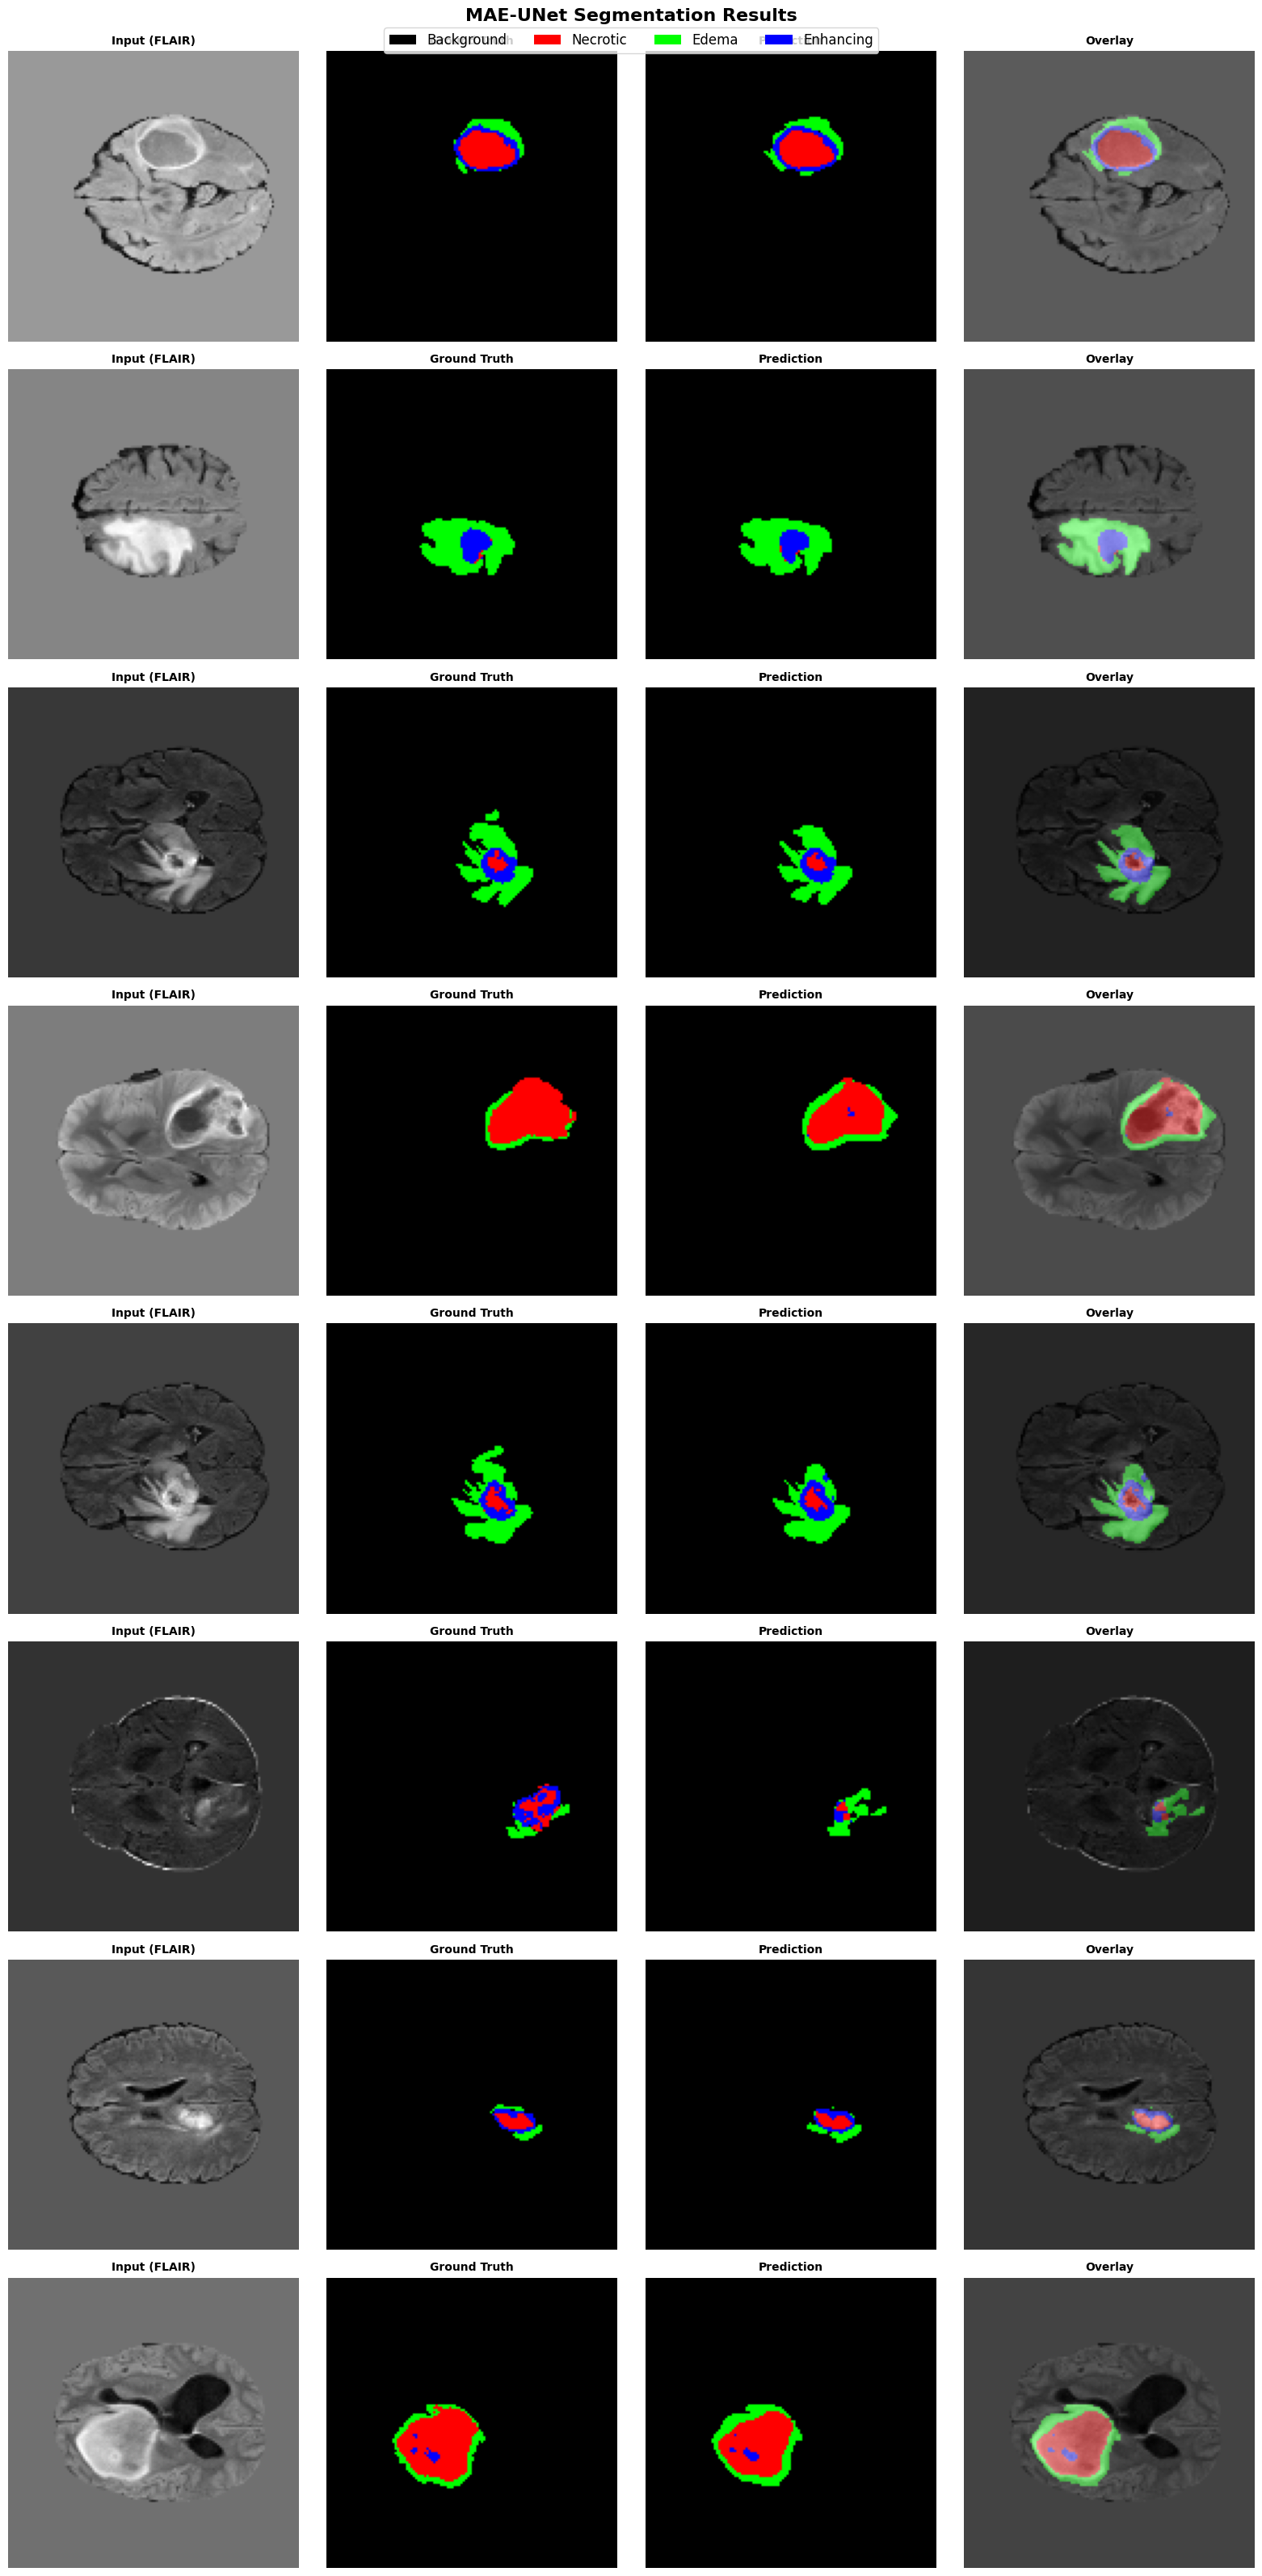

✅ Predictions visualized!


In [18]:
# Cell 18: Visualize Predictions

def plot_predictions(model, dataset, device, num_samples=8):
    """Plot prediction results"""
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            if config.MIXED_PRECISION:
                with autocast_cuda():
                    pred_logits = model(image_input)
            else:
                pred_logits = model(image_input)
            
            pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            # Convert to numpy
            image_np = image.permute(1, 2, 0).cpu().numpy()
            mask_np = mask.cpu().numpy()
            
            # Create colored masks
            mask_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_colored[mask_np == c] = colors[c]
                pred_colored[pred == c] = colors[c]
            
            # Plot
            img_display = image_np[:, :, 3]  # FLAIR channel
            img_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            
            axes[i, 0].imshow(img_display, cmap='gray')
            axes[i, 0].set_title('Input (FLAIR)', fontsize=10, fontweight='bold')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_colored)
            axes[i, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_colored)
            axes[i, 2].set_title('Prediction', fontsize=10, fontweight='bold')
            axes[i, 2].axis('off')
            
            # Overlay
            overlay = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.4
            overlay = (1 - alpha) * overlay + alpha * (pred_colored / 255.0)
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay', fontsize=10, fontweight='bold')
            axes[i, 3].axis('off')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i]/255, label=class_names[i]) for i in range(4)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
              fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.99))
    
    plt.suptitle('MAE-UNet Segmentation Results', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_PATH, 'predictions.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(unet_model, test_dataset, device, num_samples=8)
print("✅ Predictions visualized!")

In [19]:
# Cell 19: Class-wise Performance Metrics (Memory Efficient)

def compute_class_wise_metrics(model, dataloader, device):
    """Compute detailed class-wise metrics (memory efficient)"""
    
    model.eval()
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    num_classes = 4
    
    # Accumulate metrics incrementally
    tp_total = np.zeros(num_classes)
    fp_total = np.zeros(num_classes)
    fn_total = np.zeros(num_classes)
    pixel_count = np.zeros(num_classes)
    
    print("Computing class-wise metrics...")
    
    torch.cuda.empty_cache()
    gc.collect()
    
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc='Computing Metrics')):
            images = images.to(device)
            masks_np = masks.numpy()
            
            if config.MIXED_PRECISION:
                with autocast_cuda():
                    outputs = model(images)
            else:
                outputs = model(images)
            
            preds_np = torch.argmax(outputs, dim=1).cpu().numpy()
            
            del outputs, images
            
            # Compute metrics for this batch
            for class_id in range(num_classes):
                pred_binary = (preds_np == class_id).astype(np.float32)
                true_binary = (masks_np == class_id).astype(np.float32)
                
                tp_total[class_id] += np.sum((pred_binary == 1) & (true_binary == 1))
                fp_total[class_id] += np.sum((pred_binary == 1) & (true_binary == 0))
                fn_total[class_id] += np.sum((pred_binary == 0) & (true_binary == 1))
                pixel_count[class_id] += np.sum(true_binary == 1)
            
            if (batch_idx + 1) % 50 == 0:
                torch.cuda.empty_cache()
                gc.collect()
    
    # Calculate final metrics
    class_metrics = {
        'Class': [],
        'Dice': [],
        'IoU': [],
        'Precision': [],
        'Recall': [],
        'F1-Score': [],
        'Pixel Count': []
    }
    
    for class_id in range(num_classes):
        tp = tp_total[class_id]
        fp = fp_total[class_id]
        fn = fn_total[class_id]
        
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
        
        class_metrics['Class'].append(class_names[class_id])
        class_metrics['Dice'].append(dice)
        class_metrics['IoU'].append(iou)
        class_metrics['Precision'].append(precision)
        class_metrics['Recall'].append(recall)
        class_metrics['F1-Score'].append(f1)
        class_metrics['Pixel Count'].append(int(pixel_count[class_id]))
    
    return class_metrics


# Compute metrics
torch.cuda.empty_cache()
gc.collect()

class_metrics = compute_class_wise_metrics(unet_model, test_loader, device)

# Create DataFrame
df_metrics = pd.DataFrame(class_metrics)

print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE METRICS")
print("="*70)
print(df_metrics.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*70)

# Calculate mean tumor metrics (excluding background)
tumor_dice = np.mean(df_metrics['Dice'].values[1:])
tumor_iou = np.mean(df_metrics['IoU'].values[1:])

print(f"\nTUMOR-ONLY METRICS (excluding background):")
print(f"  Mean Dice: {tumor_dice:.4f} ({tumor_dice*100:.2f}%)")
print(f"  Mean IoU: {tumor_iou:.4f} ({tumor_iou*100:.2f}%)")
print("="*70)

# Save to CSV
df_metrics.to_csv(os.path.join(config.SAVE_PATH, 'class_wise_metrics.csv'), index=False)
print(f"\n✅ Metrics saved to: class_wise_metrics.csv")

torch.cuda.empty_cache()
gc.collect()

Computing class-wise metrics...


Computing Metrics: 100%|██████████| 394/394 [00:11<00:00, 33.87it/s]



CLASS-WISE PERFORMANCE METRICS
     Class   Dice    IoU  Precision  Recall  F1-Score  Pixel Count
Background 0.9969 0.9938     0.9954  0.9984    0.9969     49963509
  Necrotic 0.6639 0.4969     0.8529  0.5434    0.6639       419338
     Edema 0.7693 0.6250     0.7517  0.7877    0.7693       894607
 Enhancing 0.8035 0.6715     0.8787  0.7401    0.8035       266610

TUMOR-ONLY METRICS (excluding background):
  Mean Dice: 0.7455 (74.55%)
  Mean IoU: 0.5978 (59.78%)

✅ Metrics saved to: class_wise_metrics.csv


0

Computing confusion matrix...


Predicting: 100%|██████████| 394/394 [00:08<00:00, 43.81it/s]


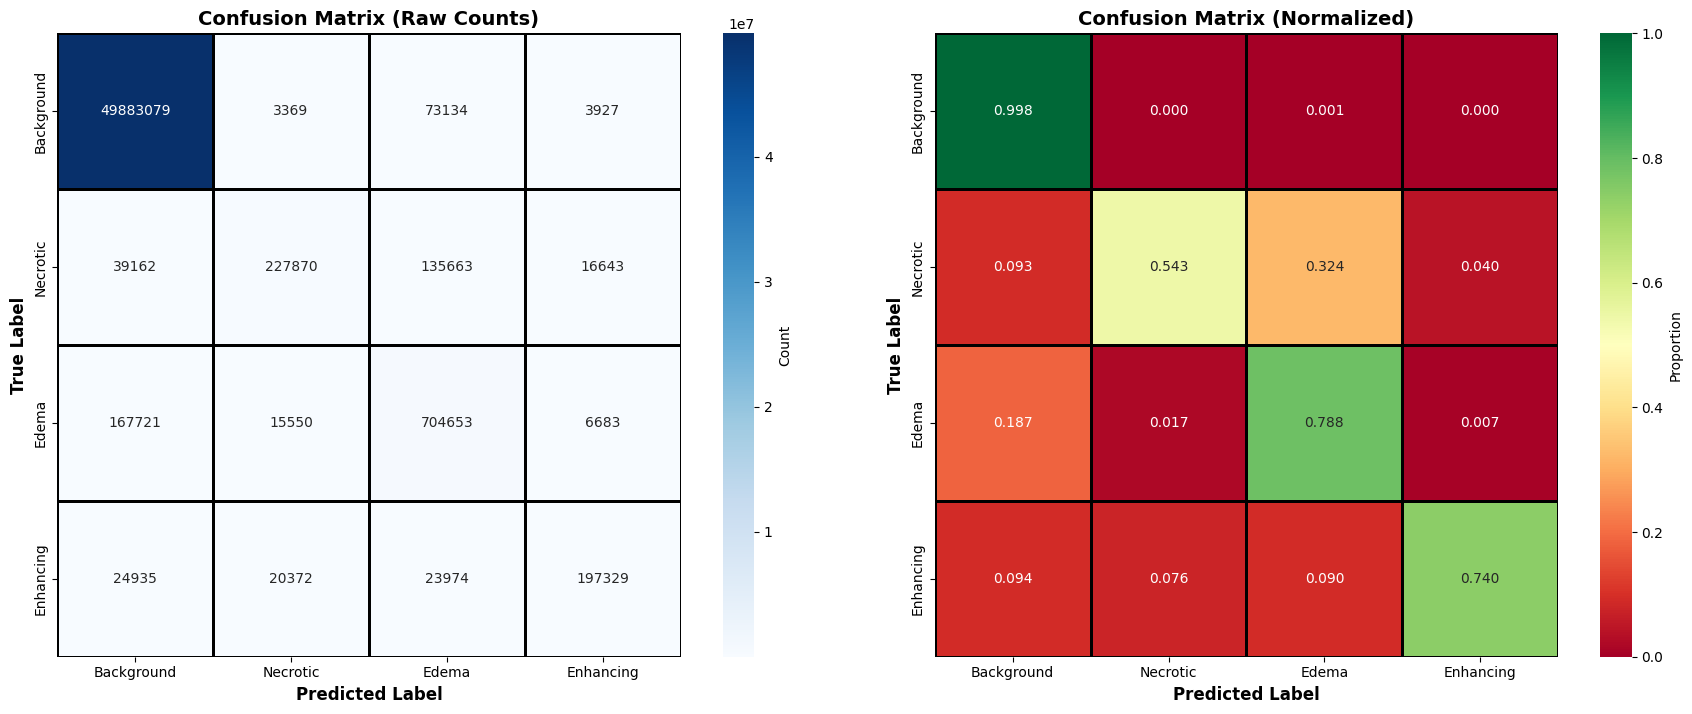


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9954    0.9984    0.9969  49963509
    Necrotic     0.8529    0.5434    0.6639    419338
       Edema     0.7517    0.7877    0.7693    894607
   Enhancing     0.8787    0.7401    0.8035    266610

    accuracy                         0.9897  51544064
   macro avg     0.8697    0.7674    0.8084  51544064
weighted avg     0.9894    0.9897    0.9892  51544064

✅ Confusion matrix saved!


13726

In [ ]:
# Cell 20: Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

def compute_confusion_matrix(model, dataloader, device):
    """Compute confusion matrix efficiently"""
    model.eval()
    
    all_preds = []
    all_true = []
    
    print("Computing confusion matrix...")
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Predicting'):
            images = images.to(device)
            
            if config.MIXED_PRECISION:
                with autocast_cuda():
                    outputs = model(images)
            else:
                outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.append(preds)
            all_true.append(masks.numpy())
            
            del outputs, images
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    
    return all_preds, all_true


# Compute predictions
all_preds, all_true = compute_confusion_matrix(unet_model, test_loader, device)

# Compute confusion matrix
y_true_flat = all_true.flatten()
y_pred_flat = all_preds.flatten()

cm = confusion_matrix(y_true_flat, y_pred_flat)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=axes[0],
            square=True, linewidths=1, linecolor='black')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'}, ax=axes[1],
            square=True, linewidths=1, linecolor='black', vmin=0, vmax=1)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
report = classification_report(
    y_true_flat, 
    y_pred_flat, 
    target_names=class_names,
    digits=4
)
print(report)
print("="*70)

# Save report
with open(os.path.join(config.SAVE_PATH, 'classification_report.txt'), 'w') as f:
    f.write(report)

print(f"✅ Confusion matrix saved!")

# Clean up
del all_preds, all_true
torch.cuda.empty_cache()
gc.collect()